# 07 – Análise de Sobrevivência
**Objetivo:** Aplicar técnicas de análise de sobrevivência para estimar as funções de probabilidade de sobrevivência ao longo do tempo de internação e modelar o risco (hazard) utilizando a Regressão de Cox.

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Configurações gráficas estritas conforme normas da instituição
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 11,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("white")
def enforce_tcc_style():
    import matplotlib.pyplot as plt
    import seaborn as sns
    try:
        plt.grid(False)
        sns.despine(top=True, right=True, left=False, bottom=False)
        for ax_ in plt.gcf().axes:
            ax_.grid(False)
            ax_.spines['top'].set_visible(False)
            ax_.spines['right'].set_visible(False)
            ax_.spines['bottom'].set_linewidth(1.5)
            ax_.spines['bottom'].set_color('black')
            ax_.spines['left'].set_linewidth(1.5)
            ax_.spines['left'].set_color('black')
            ax_.tick_params(colors='black', width=1.5)
            if ax_.get_title(): ax_.set_title('')
    except Exception: pass


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Lifelines (Survival Analysis library)
# pip install lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# sns.set_theme(style='whitegrid') # SOBRESCRITO PELO TCC
plt.rcParams['figure.figsize'] = (10, 6)
FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)


## 1. Preparação dos Dados
A análise de sobrevivência requer a variável de **tempo** (`dias_permanencia` ou `tempo_sobrevida`). Como essas variáveis foram removidas da base reduzida (para evitar vazamento no ML), usaremos a **base_modelagem.csv** original e faremos uma seleção de features manuais de interesse clínico.


In [12]:
DATA_PATH = Path('../data/processed/base_modelagem.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir formato correto
df['indicador_obito'] = pd.to_numeric(df['indicador_obito'], errors='coerce')
df['dias_permanencia'] = pd.to_numeric(df.get('quantidade_diarias', df.get('dias_permanencia', 0)), errors='coerce')
df['uti_mes_total'] = pd.to_numeric(df.get('uti_mes_total', df.get('uti_mes_total_cod', 0)), errors='coerce')

# Variáveis básicas para sobrevida
T = df['dias_permanencia'].clip(upper=30)  # Tempo (Corte clínico de 30 dias)
E = df['indicador_obito']
E = E.where(df['dias_permanencia'] <= 30, 0) # Censura pacientes que ficaram mais de 30 dias (Foco em mortalidade aguda de 30 dias) (1 = Óbito, 0 = Censura/Alta)

print(f"Base carregada. Casos totais: {len(df)}")
print(f"Óbitos confirmados: {E.sum()}")


Base carregada. Casos totais: 415367
Óbitos confirmados: 38446


## 2. Estimador de Kaplan-Meier (Curva Global)
Plotar a curva de sobrevivência global da amostra ao longo dos dias de internação.

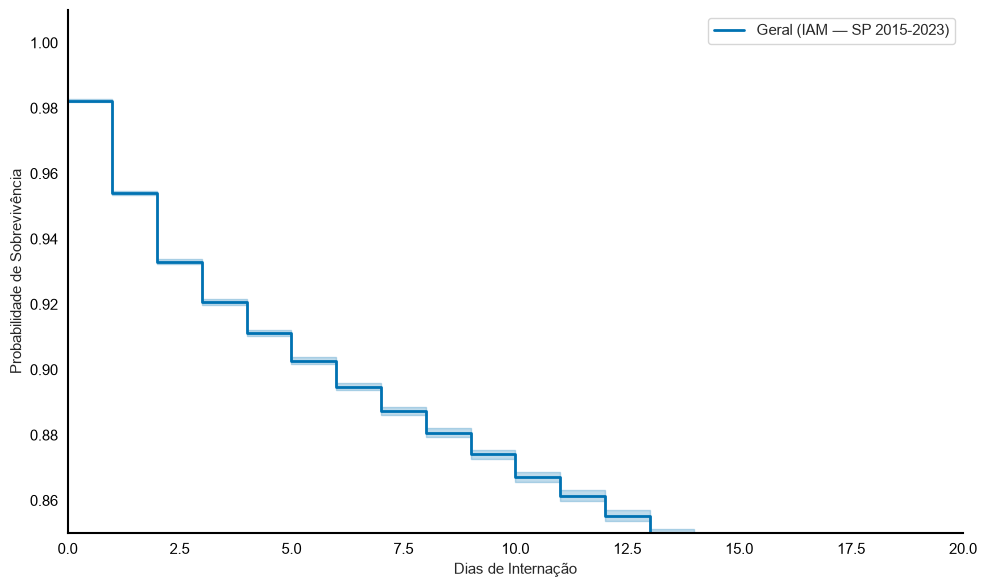

Figura salva em reports/figures/km_global.jpg
Mediana de sobrevivência: inf dias


In [13]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E, label='Geral (IAM — SP 2015-2023)')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, color='#0072B2', linewidth=2)
# ax.set_title('Curva de Sobrevivência Kaplan-Meier — IAM (SP, 2025)', fontsize=13, fontweight='bold') # TÍTULO REMOVIDO PARA TCC
ax.set_ylabel('Probabilidade de Sobrevivência')
ax.set_xlabel('Dias de Internação')
ax.set_xlim(0, 20)
ax.set_ylim(0.85, 1.01)
# ax.grid(False)  # grid desativado — norma TCC
plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'km_global.jpg', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/km_global.jpg")
print(f"Mediana de sobrevivência: {kmf.median_survival_time_} dias")


## 3. Sobrevivência Estratificada
Comparar curvas de sobrevivência entre grupos (ex: Sexo, Caráter de Atendimento) usando o Log-Rank Test.

In [14]:
print("=== Log-Rank Test (Sexo) ===")
mask_masc = df['sexo'] == 'Masculino'
mask_fem = df['sexo'] == 'Feminino'
results_sexo = logrank_test(T[mask_masc], T[mask_fem], event_observed_A=E[mask_masc], event_observed_B=E[mask_fem])
results_sexo.print_summary()

print("\n=== Log-Rank Test (Caráter de Atendimento) ===")
mask_urg = df['carater_internacao'] == 'Urgência'
mask_elet = df['carater_internacao'] == 'Eletiva'
results_urg = logrank_test(T[mask_urg], T[mask_elet], event_observed_A=E[mask_urg], event_observed_B=E[mask_elet])
results_urg.print_summary()


=== Log-Rank Test (Sexo) ===



=== Log-Rank Test (Caráter de Atendimento) ===


## 3b. Sobrevivência por Estrutura Hospitalar

Avaliando se a sobrevida difere dependendo da qualidade estrutural do hospital de atendimento (indicador construído na base enriquecida).

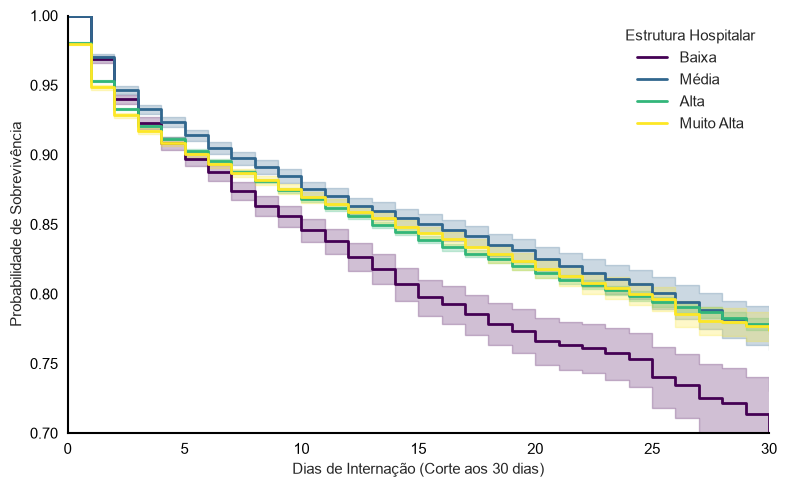

Figura salva: km_por_estrutura.jpg

Testes Log-Rank pareados entre os níveis de estrutura:

BAIXA vs MÉDIA: p-valor = 4.2151e-12  ***
BAIXA vs ALTA: p-valor = 2.6059e-02  *
BAIXA vs MUITO ALTA: p-valor = 4.9516e-01  ns
MÉDIA vs ALTA: p-valor = 6.1710e-09  ***
MÉDIA vs MUITO ALTA: p-valor = 2.0927e-11  ***
ALTA vs MUITO ALTA: p-valor = 2.1103e-02  *


In [15]:
import matplotlib.pyplot as plt
import numpy as np

_vir = plt.cm.viridis

# Carrega a base enriquecida para usar a categoria agrupada
df_enriched = pd.read_csv("../data/processed/base_modelagem_enriched.csv", low_memory=False)

if df_enriched.index.name != 'codigo_internacao':
    if 'codigo_internacao' in df_enriched.columns:
        df_enriched.set_index('codigo_internacao', inplace=True)
    else:
        df_enriched.index = df.index

df["categoria_estrutura"] = df_enriched["categoria_estrutura"].values

# Viridis igualmente espaçado para os 4 níveis de estrutura
estrutura_config = {
    "baixa":     ("Baixa",      _vir(0.0)),
    "média":     ("Média",      _vir(0.33)),
    "alta":      ("Alta",       _vir(0.66)),
    "muito alta":("Muito Alta", _vir(1.0)),
}

fig, ax = plt.subplots(figsize=(8, 5))

for cat, (label, cor) in estrutura_config.items():
    mask = df["categoria_estrutura"] == cat
    if mask.sum() < 10:
        continue
    kmf_tmp = KaplanMeierFitter()
    kmf_tmp.fit(df.loc[mask, "dias_permanencia"], df.loc[mask, "indicador_obito"], label=label)
    kmf_tmp.plot_survival_function(ax=ax, color=cor, linewidth=2)

ax.set_ylabel("Probabilidade de Sobrevivência")
ax.set_xlabel("Dias de Internação (Corte aos 30 dias)")
ax.set_xlim(0, 30)
ax.set_ylim(0.70, 1.0)
ax.legend(title="Estrutura Hospitalar", frameon=False)
ax.set_title('')   # TÍTULO REMOVIDO — norma TCC
ax.grid(False)

enforce_tcc_style()
plt.tight_layout()
plt.savefig(FIG_PATH / "km_por_estrutura.jpg", dpi=300)
plt.show()
print("Figura salva: km_por_estrutura.jpg")

print("\n" + "="*50)
print("Testes Log-Rank pareados entre os níveis de estrutura:\n")
from itertools import combinations
categorias = ["baixa", "média", "alta", "muito alta"]
for cat1, cat2 in combinations(categorias, 2):
    mask1 = df["categoria_estrutura"] == cat1
    mask2 = df["categoria_estrutura"] == cat2
    results = logrank_test(
        df.loc[mask1, "dias_permanencia"], df.loc[mask2, "dias_permanencia"],
        event_observed_A=df.loc[mask1, "indicador_obito"],
        event_observed_B=df.loc[mask2, "indicador_obito"]
    )
    sig = '***' if results.p_value < 0.001 else ('**' if results.p_value < 0.01 else ('*' if results.p_value < 0.05 else 'ns'))
    print(f"{cat1.upper()} vs {cat2.upper()}: p-valor = {results.p_value:.4e}  {sig}")


## 3c. Sobrevivência por Faixa Etária

Estratificação das curvas de Kaplan-Meier por faixa etária, com teste de Log-Rank para avaliação de significância das diferenças entre grupos.

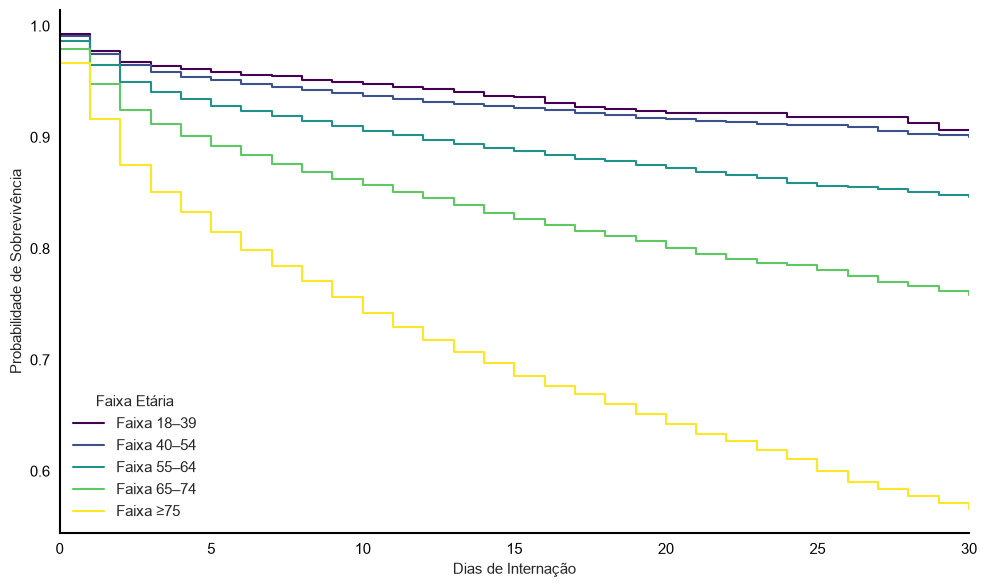

Figura salva: km_faixa_etaria.jpg
=== Log-Rank Test — Faixa Etária ===
  18–39  vs 40–54   p = 2.0080e-03  **
  18–39  vs 55–64   p = 3.8658e-32  ***
  18–39  vs 65–74   p = 6.1092e-109  ***
  18–39  vs ≥75     p = 0.0000e+00  ***
  40–54  vs 55–64   p = 4.6157e-92  ***
  40–54  vs 65–74   p = 0.0000e+00  ***
  40–54  vs ≥75     p = 0.0000e+00  ***
  55–64  vs 65–74   p = 6.0798e-215  ***
  55–64  vs ≥75     p = 0.0000e+00  ***
  65–74  vs ≥75     p = 0.0000e+00  ***


In [16]:
import matplotlib.pyplot as plt
import numpy as np

_vir = plt.cm.viridis

# Criar faixa etária (se não existir)
if 'faixa_etaria' not in df.columns:
    bins   = [18, 40, 55, 65, 75, df['idade'].max() + 1]
    labels = ['18–39', '40–54', '55–64', '65–74', '≥75']
    df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=False)

grupos_fx = df['faixa_etaria'].cat.categories.tolist()
n_fx = len(grupos_fx)
palette_fx = [_vir(i / max(n_fx - 1, 1)) for i in range(n_fx)]

fig, ax = plt.subplots(figsize=(10, 6))

kmf_fx = KaplanMeierFitter()
for grupo, cor in zip(grupos_fx, palette_fx):
    mask = df['faixa_etaria'] == grupo
    if mask.sum() < 10:
        continue
    kmf_fx.fit(T[mask], event_observed=E[mask], label=f'Faixa {grupo}')
    kmf_fx.plot_survival_function(ax=ax, color=cor, ci_show=False)

ax.set_xlim(0, 30)
ax.set_xlabel('Dias de Internação')
ax.set_ylabel('Probabilidade de Sobrevivência')
ax.set_title('')   # TÍTULO REMOVIDO — norma TCC
ax.legend(title='Faixa Etária', frameon=False)
ax.grid(False)

enforce_tcc_style()
plt.tight_layout()
plt.savefig('../reports/figures/km_faixa_etaria.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: km_faixa_etaria.jpg')

# ── Log-Rank pareado por faixa etária ─────────────────────────────────────────
print('=== Log-Rank Test — Faixa Etária ===')
from itertools import combinations
for ga, gb in combinations(grupos_fx, 2):
    ma = df['faixa_etaria'] == ga
    mb = df['faixa_etaria'] == gb
    if ma.sum() < 10 or mb.sum() < 10:
        continue
    res = logrank_test(T[ma], T[mb], event_observed_A=E[ma], event_observed_B=E[mb])
    sig = '***' if res.p_value < 0.001 else ('**' if res.p_value < 0.01 else ('*' if res.p_value < 0.05 else 'ns'))
    print(f'  {str(ga):<6} vs {str(gb):<6}  p = {res.p_value:.4e}  {sig}')


## 3d. Sobrevivência por Raça/Cor

Estratificação das curvas de Kaplan-Meier por raça/cor do paciente, com teste de Log-Rank. 
Esta análise complementa a análise de justiça algorítmica (Fairness — NB06).

Usando coluna: raca_cor
raca_cor
Branca            240660
Parda             105588
Sem informação     45184
Preta              19999
Amarela             3900
Indígena              36
Name: count, dtype: int64



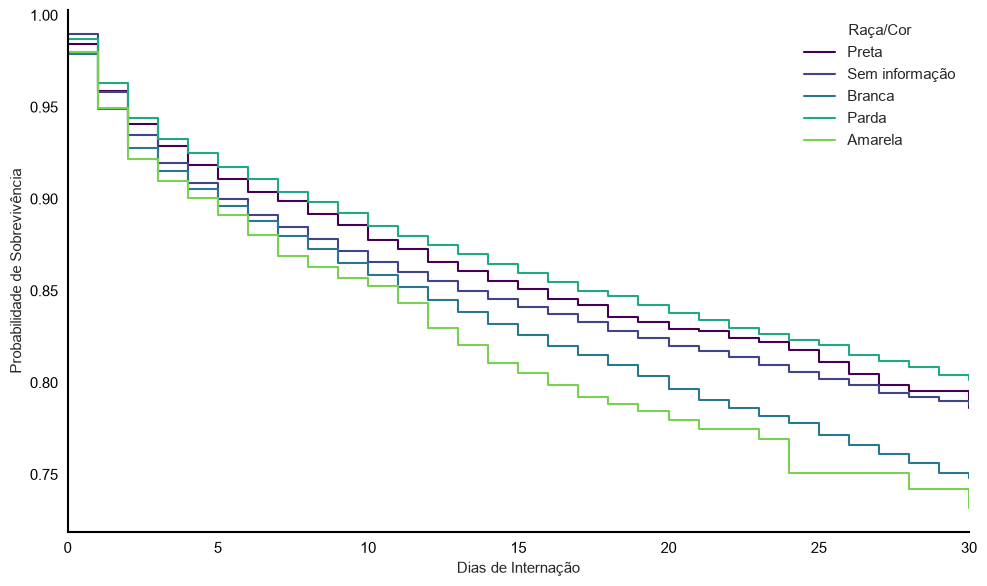

Figura salva: km_raca_cor.jpg
=== Log-Rank Test — Raça/Cor ===
  Preta                vs Sem informação        p = 3.9713e-03  **
  Preta                vs Branca                p = 3.0451e-13  ***
  Preta                vs Parda                 p = 5.5203e-03  **
  Preta                vs Amarela               p = 8.6923e-06  ***
  Sem informação       vs Branca                p = 1.4433e-10  ***
  Sem informação       vs Parda                 p = 8.2739e-18  ***
  Sem informação       vs Amarela               p = 9.6696e-04  ***
  Branca               vs Parda                 p = 2.5157e-92  ***
  Branca               vs Amarela               p = 2.1683e-01  ns
  Parda                vs Amarela               p = 3.2106e-10  ***


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

_vir = plt.cm.viridis

raca_col = next((c for c in df.columns if 'ra' in c.lower() and ('cor' in c.lower() or 'ça' in c.lower())), None)
if raca_col is None:
    raca_col = next((c for c in df.columns if c.lower() in ['raca', 'raca_cor', 'cor', 'raca_label', 'cor_label']), None)

if raca_col is None:
    print('⚠️  Coluna de raça/cor não encontrada. Colunas disponíveis:')
    print([c for c in df.columns if len(c) < 30][:30])
else:
    print(f'Usando coluna: {raca_col}')
    print(df[raca_col].value_counts())
    print()

    grupos_raca = df[raca_col].dropna().unique().tolist()
    n_raca = len(grupos_raca)
    palette_raca = [_vir(i / max(n_raca - 1, 1)) for i in range(n_raca)]

    fig, ax = plt.subplots(figsize=(10, 6))
    kmf_raca = KaplanMeierFitter()

    for grupo, cor in zip(grupos_raca, palette_raca):
        mask = df[raca_col] == grupo
        if mask.sum() < 50:
            continue
        kmf_raca.fit(T[mask], event_observed=E[mask], label=str(grupo))
        kmf_raca.plot_survival_function(ax=ax, color=cor, ci_show=False)

    ax.set_xlim(0, 30)
    ax.set_xlabel('Dias de Internação')
    ax.set_ylabel('Probabilidade de Sobrevivência')
    ax.set_title('')   # TÍTULO REMOVIDO — norma TCC
    ax.legend(title='Raça/Cor', frameon=False)
    ax.grid(False)

    enforce_tcc_style()
    plt.tight_layout()
    plt.savefig('../reports/figures/km_raca_cor.jpg', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figura salva: km_raca_cor.jpg')

    # ── Log-Rank pareado ──────────────────────────────────────────────────────
    print('=== Log-Rank Test — Raça/Cor ===')
    grupos_validos = [g for g in grupos_raca if (df[raca_col] == g).sum() >= 50]
    for ga, gb in combinations(grupos_validos, 2):
        ma = df[raca_col] == ga
        mb = df[raca_col] == gb
        res = logrank_test(T[ma], T[mb], event_observed_A=E[ma], event_observed_B=E[mb])
        sig = '***' if res.p_value < 0.001 else ('**' if res.p_value < 0.01 else ('*' if res.p_value < 0.05 else 'ns'))
        print(f'  {str(ga):<20} vs {str(gb):<20}  p = {res.p_value:.4e}  {sig}')


## 4. Modelo de Riscos Proporcionais de Cox (CoxPH)
O modelo de Cox permite avaliar o efeito de múltiplas variáveis independentes sobre o risco de ocorrência do óbito (Hazard Ratio).

/tmp/ipykernel_2852869/2884972406.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cox.loc[df_cox['dias_permanencia'] <= 0, 'dias_permanencia'] = 0.1


Variável complexidade_alta removida por variância zero.
=== Modelo de Riscos Proporcionais de Cox ===
Covariáveis: idade, sexo, carater_internacao, escore_estrutura
(uti_mes_total removida — variável pós-admissão, potencial leakage)



<lifelines.CoxPHFitter: fitted with 415367 total observations, 376921 right-censored observations>
             duration col = 'dias_permanencia'
                event col = 'indicador_obito'
      baseline estimation = breslow
   number of observations = 415367
number of events observed = 38446
   partial log-likelihood = -469766.00
         time fit was run = 2026-09-18 20:12:55 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
idade               0.04      1.04      0.00            0.04            0.04                1.04                1.05
sexo                0.11      1.12      0.01            0.09            0.13                1.10                1.14
carater_internacao  0.55      1.74      0.03            0.50            0.60                1.66                1.83
escore_estrutura    0.05      1.05      0.01            0.03            0.06                1.03                1.07

                    cmp to     z      p  -log2(p)
covariate                                        
idade                 0.00 99.40 <0.005       inf
sexo                  0.00 10.72 <0.005     86.66
carater_internacao    0.00 21.64 <0.005    342.55
escore_estrutura      0.00  6.13 <0.005     30.12
---
Concordance = 0.65
Partial AIC = 939540.00
log-likelihood ratio test = 11590.27 on 4 df
-log2(p) of ll-ratio test = inf

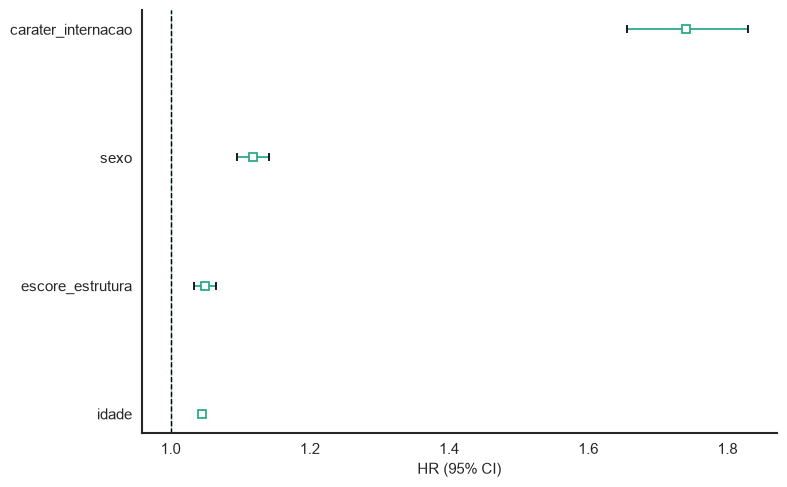

Figura salva: cox_hazard_ratios.jpg


In [18]:
import matplotlib.pyplot as plt

# ── Preparar dados para Cox ──────────────────────────────────────────────────
# NOTA: uti_mes_total é removida — variável pós-admissão (data leakage).
# A estrutura hospitalar (escore_estrutura) é incorporada como covariável do CNES.

if 'escore_estrutura' not in df.columns:
    df_enr = pd.read_csv('../data/processed/base_modelagem_enriched.csv',
                          usecols=['ano_competencia', 'escore_estrutura'], low_memory=False)
    df['escore_estrutura'] = df_enr['escore_estrutura'].values

cols_cox = ['dias_permanencia', 'indicador_obito', 'idade', 'sexo', 'carater_internacao', 'complexidade_cod', 'escore_estrutura']
df_cox = df[cols_cox].copy().dropna()
df_cox.loc[df_cox['dias_permanencia'] > 30, 'indicador_obito'] = 0
df_cox['dias_permanencia'] = df_cox['dias_permanencia'].clip(upper=30)
df_cox['sexo']               = (df_cox['sexo'] == 'Feminino').astype(int)
df_cox['carater_internacao'] = (df_cox['carater_internacao'] == 'Urgência').astype(int)
df_cox['complexidade_alta'] = (df_cox['complexidade_cod'].astype(str).str.contains('03|Alta', case=False, na=False)).astype(int)
df_cox.drop(columns=['complexidade_cod'], inplace=True)

# Correção para o erro de Convergência (Delta contains NaN):
# 1. Tempos exatamente iguais a 0 (óbito ou alta no mesmo dia de admissão) quebram o logaritmo em alguns casos.
df_cox.loc[df_cox['dias_permanencia'] <= 0, 'dias_permanencia'] = 0.1

# 2. Se a variável complexidade não teve variância (ex: formato de dado numérico não bateu com a string), descartamos.
if df_cox['complexidade_alta'].var() == 0:
    df_cox.drop(columns=['complexidade_alta'], inplace=True)
    print('Variável complexidade_alta removida por variância zero.')

# escore_estrutura: 0=baixa → 3=muito alta (ordinal numérica)

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='dias_permanencia', event_col='indicador_obito')

print('=== Modelo de Riscos Proporcionais de Cox ===')
print('Covariáveis: idade, sexo, carater_internacao, escore_estrutura')
print('(uti_mes_total removida — variável pós-admissão, potencial leakage)')
print()
cph.print_summary()

# ── Forest Plot — Hazard Ratios com IC 95% ────────────────────────────────────
_vir_color = plt.cm.viridis(0.6)   # cor viridis para pontos e CI bars

fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax, hazard_ratios=True)   # lifelines não aceita color= diretamente

# Recolorir os elementos gerados pelo lifelines para viridis
for line in ax.lines:
    line.set_color(_vir_color)
for col in ax.collections:
    try:
        col.set_facecolor(_vir_color)
        col.set_edgecolor(_vir_color)
    except Exception:
        pass

ax.set_title('')   # TÍTULO REMOVIDO — norma TCC
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='HR = 1')

plt.tight_layout()
plt.savefig('../reports/figures/cox_hazard_ratios.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: cox_hazard_ratios.jpg')


## 5. Teste de Resíduos de Schoenfeld — Premissa de Riscos Proporcionais

O modelo de Cox assume que os **hazard ratios são constantes ao longo do tempo** (premissa de riscos proporcionais). O teste de resíduos de Schoenfeld testa formalmente essa premissa: **H₀: riscos são proporcionais** (resíduos sem tendência temporal). Um p-valor < 0,05 indica violação da premissa para aquela covariável.


In [19]:
from lifelines.statistics import proportional_hazard_test

results_schoenfeld = proportional_hazard_test(
    cph,
    df_cox,
    time_transform='rank'
)

print('=== Teste de Resíduos de Schoenfeld ===')
print('Covariáveis testadas: idade, sexo, carater_internacao, escore_estrutura')
print('H0: riscos são proporcionais (sem tendência temporal nos resíduos)')
print()
results_schoenfeld.print_summary()
print()
for covar in cph.params_.index:
    row = results_schoenfeld.summary.loc[covar]
    p   = row['p']
    sig = '*** VIOLA' if p < 0.001 else ('** VIOLA' if p < 0.01 else
          ('* VIOLA' if p < 0.05 else 'OK (proporcional)'))
    print(f'  {covar:<25}  p = {p:.4e}  → {sig}')


=== Teste de Resíduos de Schoenfeld ===
Covariáveis testadas: idade, sexo, carater_internacao, escore_estrutura
H0: riscos são proporcionais (sem tendência temporal nos resíduos)




  idade                      p = 2.2810e-73  → *** VIOLA
  sexo                       p = 4.3047e-01  → OK (proporcional)
  carater_internacao         p = 9.6458e-01  → OK (proporcional)
  escore_estrutura           p = 6.7965e-100  → *** VIOLA
